# Is het verdamping?

In dit experiment is er een verwarmingselement in een met water gevulde maatbeker gestopt. Elke minuut is de temperatuur van het water gemeten. Deze metingen zijn opgeslagen in [tempmetingen.csv](tempmetingen.csv).

Verder is gegeven dat: 
$m_{maatbeker} = 820.8 \mathrm{gr}$  
$m_{maatbeker + water, start} = 1292.9 \mathrm{gr}$  
$m_{maatbeker + water, eind} = 1274.9 \mathrm{gr}$

Het moge duidelijk zijn dat er water is 'verdwenen'. Ook is de eindtemperatuur van het water niet gelijk aan een proces waarbij verdamping en eventuele warmteverliezen niet meegenomen worden. 

```{exercise}
Onderzoek het proces door:
1. De plot van de metingen te maken, inclusief een verwachte trendlijn voor de temperatuur van het water als al de toegevoerde warmte gaat zitten in het water.
2. Bepaal of de totale hoeveelheid toegevoegde energie correspondeert met de opwarming en verdamping van het water, geef daarbij de aannames die je doet.
3. Geef aanbevelingen voor een verbetering van het experiment om (nog) beter het thermodynamische proces te kunnen onderzoeken en beschrijven.
```

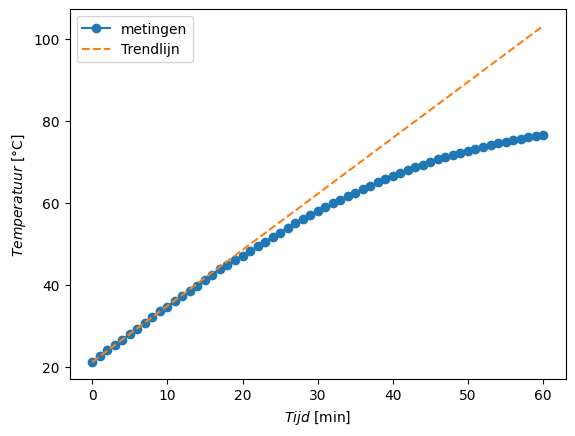

Vermogen P = 44.9 W
Totale toegevoerde energie in water: 161817 J
Energie voor opwarming: 109325 J
Energie voor verdamping: 40680 J
Totaal gebruikt (opwarming + verdamping): 150005 J
Verschil (toegevoegd - gebruikt): 11812 J


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Gegevens maatbeker (mb) en van 'alleen' water (w)
m_mb = 820.8 # in g
m_mb_i= 1292.9 # in g
m_mb_e= 1274.9 # in g

m_w_i = (m_mb_i - m_mb)/1000 # in kg
m_w_e = (m_mb_e - m_mb)/1000 # in kg
m_w_damp = (m_w_i - m_w_e) # verdamping in kg
# print(m_w_i, m_w_e, m_w_damp)

# Gegevens metingen
data = np.loadtxt('tempmetingen.csv', delimiter=';', skiprows=1)
t, T = data[:,0], data[:,1]
# print (t, T)

# Trendlijn
def lineair(t, a, b):
    return a * t + b
N = 10
popt, pcov = curve_fit(lineair, t[:N], T[:N])
a, b = popt
T_trend = lineair(t, a, b)

plt.figure()
plt.plot(t, T, 'o-', label= 'metingen')
plt.plot(t, T_trend, '--', label="Trendlijn")
plt.xlabel("$Tijd$ [min]")
plt.ylabel("$Temperatuur$ [°C]")
plt.legend()
plt.show()

# Opdracht 2
c = 4180  # J/(kg K)
a_s = a / 60  # °C/min naar °C/s
P = m_w_i * c * a_s  # Watt
print(f"Vermogen P = {P:.1f} W")

t_tot = t[-1] * 60 # in secondes
E_toegevoegd = P * t_tot #Joule
print(f"Totale toegevoerde energie in water: {E_toegevoegd:.0f} J")

delta_T = T[-1] - T[0]
E_warm = m_w_i * c * delta_T #Joule
print(f"Energie voor opwarming: {E_warm:.0f} J")

L_v = 2.26e6  # J/kg
E_damp = m_w_damp * L_v #Joule
print(f"Energie voor verdamping: {E_damp:.0f} J")

E_gebruikt = E_warm + E_damp
print(f"Totaal gebruikt (opwarming + verdamping): {E_gebruikt:.0f} J")

# Verschil tussen toegevoegde en gebruikte
verschil = E_toegevoegd - E_gebruikt
print(f"Verschil (toegevoegd - gebruikt): {verschil:.0f} J")


# Genomen aannames
Er zijn de volgende aannames genomen:
De soortelijke warmte van water is als constant beschouwd, er is ervan uitgegaan dat de temperatuur overal in het water een hetzelfde temperaturen zijn (homogene temperatuur), de maatbeker is verwaarloosd en neemt geen warmte weg, bij de trendlijn en berekening van de vermogen uitgegaan dat dat alle toegeveorde energie naar het water gaat en dat de vermogen constant is gehouden.

Opdracht 3: Aanbevelingen voor verbeteringen

1. Om het een nog betere Thermodynamisch proces ervan te maken kan er gebruik gemaakt worden van een betere isolatie materiaal om (meer) warmteverlies te beperken dan een maatbeker.
2. Mogelijke omgevingstemperaturen te meten om de warmteverlies exacter te bepalen.
3. Om de toegevoerde energie te bapelen, de elektrische vermogen van het verwarmingselement aan te sluiten met een meter.
4. Mogelijk de warmteopname van de maatbeker te meten en daarmee ook meebrengen in de berekeningen.
5. De verdamping van water op te vangen door middel van een bijvoorbeeld een condensator om de massa exacter te bepalen.